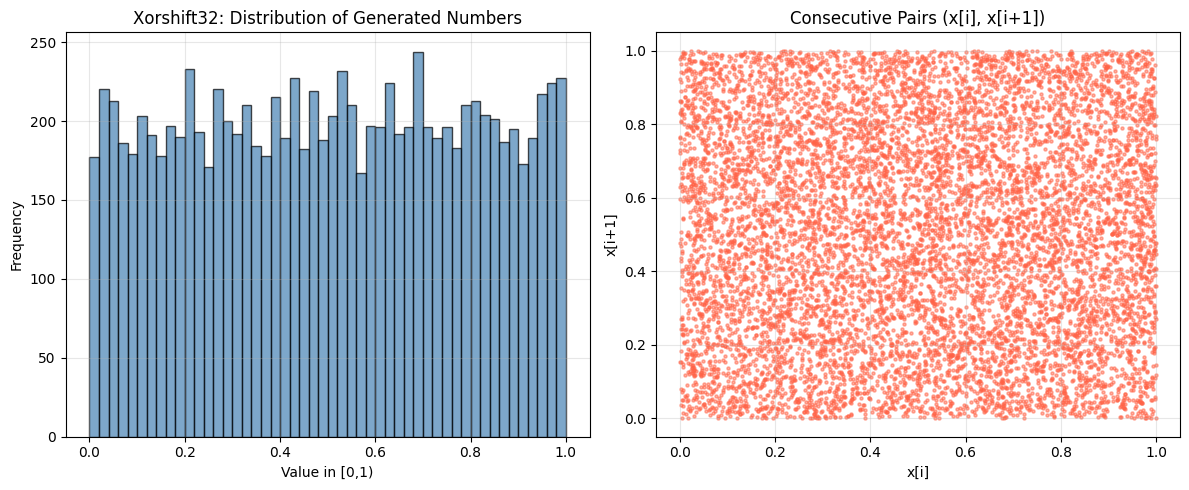

In [1]:
#!/usr/bin/env python3
"""
Visualize the Xorshift pseudorandom number generator (PRNG) in Python.

We'll generate a sequence of 32-bit unsigned integers using a simple
Xorshift variant, then:
  1) Plot a histogram of the generated values (to check the distribution).
  2) Plot a scatter plot of consecutive pairs to see if there's any pattern.

Xorshift references:
  - George Marsaglia (2003). "Xorshift RNGs".
"""

import matplotlib.pyplot as plt
import numpy as np

def xorshift32(state=123456789, size=10000):
    """
    Generate `size` pseudorandom 32-bit unsigned integers using a simple
    xorshift32 algorithm. Returns a NumPy array of shape (size,).

    Parameters:
        state (int): Initial seed (nonzero).
        size (int): Number of random values to generate.
    """
    # Ensure state is within 32-bit range:
    state &= 0xFFFFFFFF

    output = np.zeros(size, dtype=np.uint32)

    for i in range(size):
        # Xorshift32 step:
        #  1) Shift left by 13
        #  2) XOR
        #  3) Shift right by 17
        #  4) XOR
        #  5) Shift left by 5
        #  6) XOR
        state ^= (state << 13) & 0xFFFFFFFF
        state ^= (state >> 17) & 0xFFFFFFFF
        state ^= (state << 5) & 0xFFFFFFFF

        output[i] = state

    return output

def main():
    # Generate 10,000 random values
    rng_values = xorshift32(state=2023, size=10000)

    # Convert to float in [0, 1) range for histogram
    # (Divide by 2^32 to normalize)
    float_values = rng_values.astype(np.float64) / 2**32

    # 1) Plot histogram of distribution
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.hist(float_values, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    plt.title("Xorshift32: Distribution of Generated Numbers")
    plt.xlabel("Value in [0,1)")
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)

    # 2) Scatter plot of consecutive pairs to reveal correlation
    plt.subplot(1, 2, 2)
    # We'll plot (value[i], value[i+1]) for i in 0..(n-2)
    x_vals = float_values[:-1]
    y_vals = float_values[1:]
    plt.scatter(x_vals, y_vals, s=5, alpha=0.5, c='tomato')
    plt.title("Consecutive Pairs (x[i], x[i+1])")
    plt.xlabel("x[i]")
    plt.ylabel("x[i+1]")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()


That scatter plot is showing pairs of consecutive outputs from the random number generator—specifically, each dot represents
(
𝑥
[
𝑖
]
,
𝑥
[
𝑖
+
1
]
)
(x[i],x[i+1]). If there were noticeable lines or clusters, it would indicate correlation between consecutive values. Instead, seeing a fairly uniform “cloud” of points suggests that consecutive outputs do not exhibit strong patterns or correlations, which is what we want to see in a good PRNG.